In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../../DATA/Telco-Customer-Churn.csv')

Анализ будет проводится на основе признака tenure

<Axes: xlabel='tenure', ylabel='Count'>

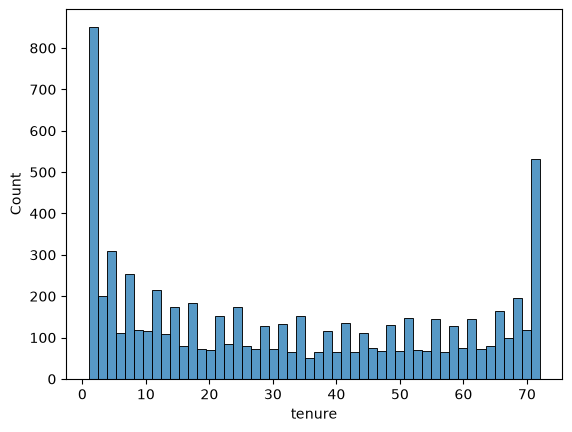

In [3]:
sns.histplot(data=df, x="tenure", bins=50)

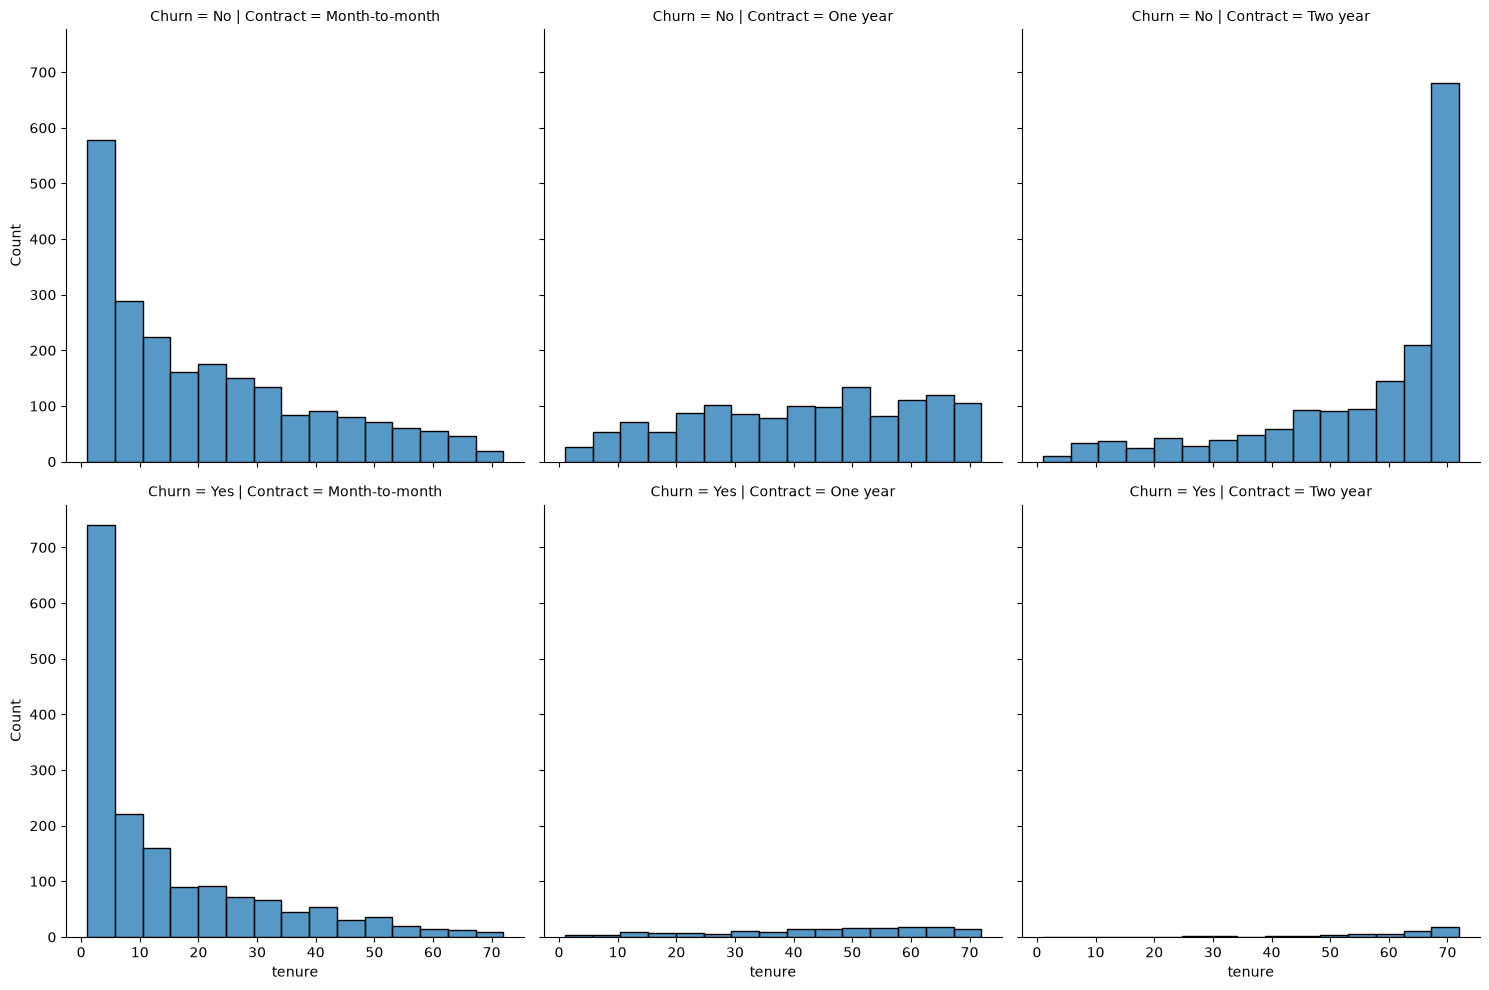

In [4]:
sns.displot(data=df, x="tenure", row="Churn", col="Contract")

<Axes: xlabel='TotalCharges', ylabel='MonthlyCharges'>

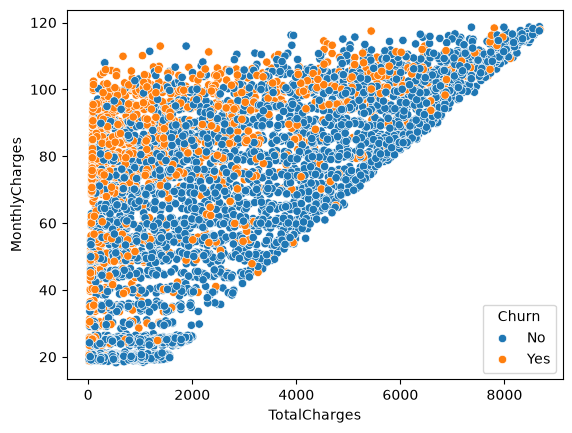

In [5]:
sns.scatterplot(data=df, x="TotalCharges", y="MonthlyCharges", hue="Churn")

Тут тоже самое что видели раньше,
большие ежемесячные расходы и низкие общие сильно увеличивают шанс оттока

# Когортный анализ

In [6]:
unique_cohort = df["tenure"].unique()

In [7]:
unique_cohort

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39])

In [8]:
group_by_tenure = df.groupby("tenure")["Churn"].value_counts()

In [16]:
dict_cohort = {}
for i in unique_cohort:
    count_yes = group_by_tenure.loc[i].loc["Yes"]
    count_no = group_by_tenure.loc[i].loc["No"]
    dict_cohort[i] = count_yes/(count_yes + count_no) * 100

In [19]:
series_group = pd.Series(dict_cohort).sort_index()

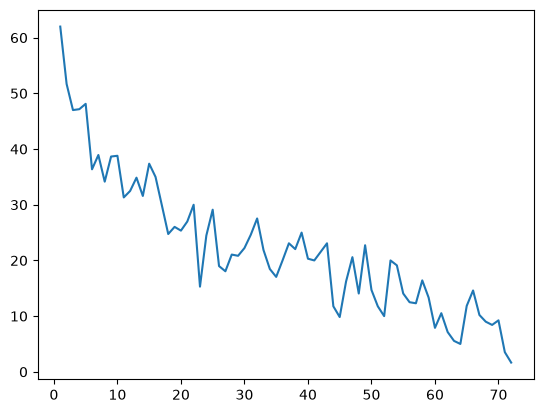

In [21]:
plt.plot(series_group.index, series_group.values)

In [23]:
def cohort(tenure):
    if tenure < 12:
        return "Меньше года"
    if tenure < 24:
        return "Меньше 2 лет"
    if tenure < 36:
        return "Меньше 3 лет"
    return "Больше 3 лет"

In [24]:
df['Cohort'] = df["tenure"].apply(cohort)

In [25]:
df["Cohort"]

0        Меньше года
1       Меньше 3 лет
2        Меньше года
3       Больше 3 лет
4        Меньше года
            ...     
7027    Меньше 3 лет
7028    Больше 3 лет
7029     Меньше года
7030     Меньше года
7031    Больше 3 лет
Name: Cohort, Length: 7032, dtype: object

<Axes: xlabel='TotalCharges', ylabel='MonthlyCharges'>

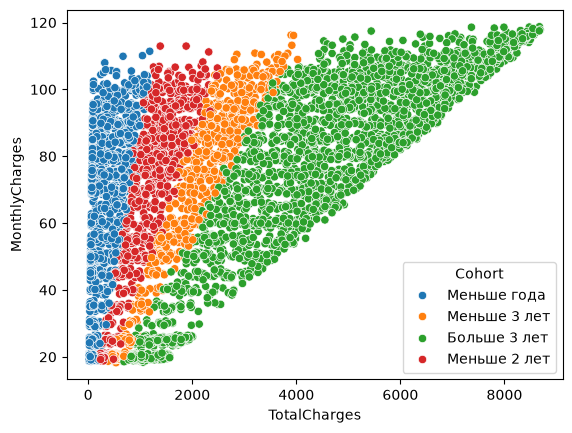

In [26]:
sns.scatterplot(data=df, x="TotalCharges", y="MonthlyCharges", hue="Cohort")

Без преувеличения легло очень четко, (признак все равно лишний, ансамбль сам найдет порог)

<Axes: xlabel='Churn', ylabel='count'>

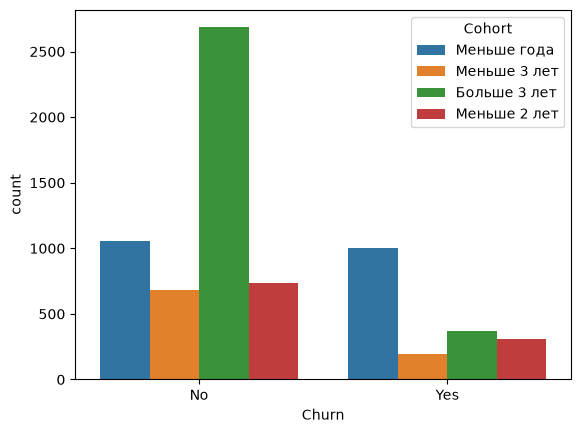

In [27]:
sns.countplot(data=df, x="Churn", hue="Cohort")

Признак очень полезен: явно разделет отток, особенно пользователей которые уже долгое время пользются услугами

<Figure size 3000x2000 with 0 Axes>

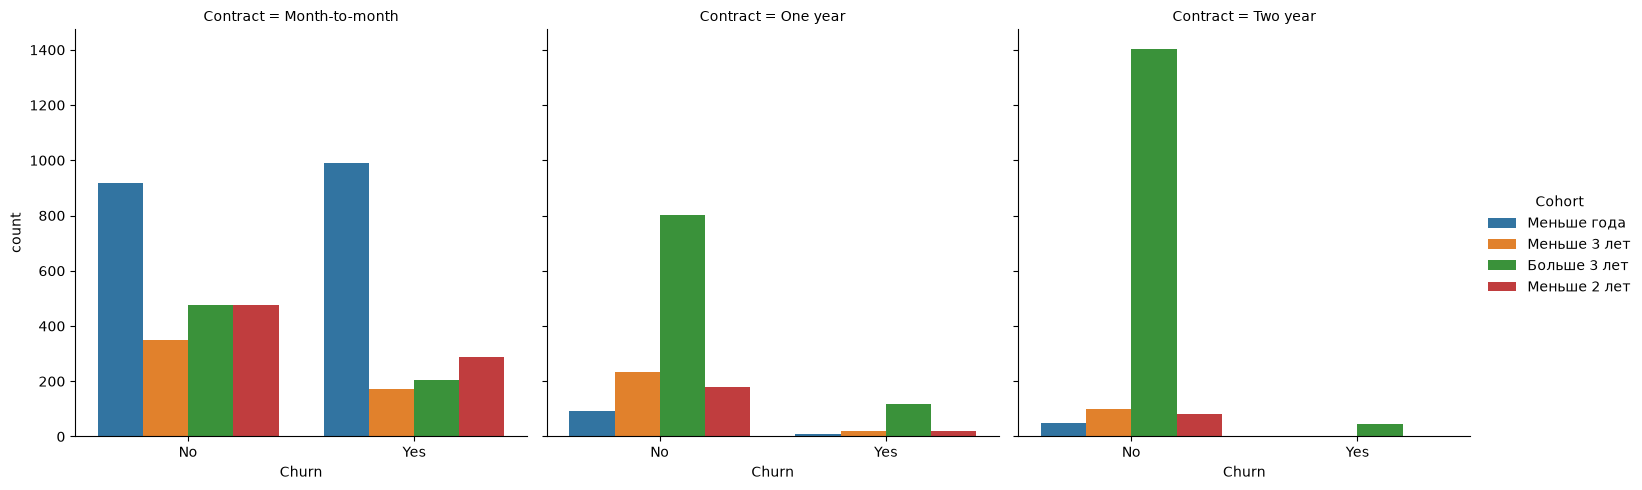

In [36]:
plt.figure(figsize=(15,10), dpi=200)
sns.catplot(data=df, x="Churn", hue="Cohort", col="Contract", kind="count")